# ML-02 — Research Question and Provisional Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/khaled-dragon/ML-intern/blob/main/work/notebooks/w01_research_question.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. My lane (or freestyle) and why

*Name your lane — or say 'freestyle' and describe your own question. One short paragraph: why this one?*

I'm going freestyle with a Growth / Recovery / Momentum Prediction question,
built on top of the daily performance facts. I picked this over the four
predefined lanes because it involves training an actual predictive model
(not just ranking or clustering), and because getting the leakage control
right (making sure future information never sneaks into the features) is a
real technical challenge I want to work through properly.

## 2. The question: decision, action, cost of a wrong call

*What decision does your work improve? Who acts on it? What does a wrong recommendation cost?*

**The question:** Given a page's performance signals over the prior 90 days
(impressions, clicks, average position, CTR, sessions), can I predict whether
it is likely to decline, stay flat, or gain momentum over the next 30 days?

**Unit of analysis:** one content item (content_hash_id), for one client, at
one point in time — using a prior-90-day feature window to predict a
next-30-day outcome window.

**The decision this improves:** which pages a content review team should look
at proactively, before a decline is already obvious, versus reactively.

**Who acts on it:** a content strategist or SEO reviewer with limited review
capacity per week (they can't check every page).

**The action they'd take:** for pages flagged "likely to decline," prioritize
them for a refresh or protective content update. For pages flagged "likely to
gain momentum," consider expanding or supporting them further while they're
already trending up.

**Cost of a wrong call:** a false positive (flagged as declining but it wasn't)
wastes reviewer time that could've gone to a real problem page. A false
negative (a real decline missed) means the team reacts late, after traffic is
already lost — which is more expensive to recover from than to prevent.

**Why data/ML helps here:** with hundreds of thousands of content items and
limited reviewer time, nobody can manually track every page's trajectory.
A model that ranks pages by predicted future risk or opportunity turns an
impossible manual task into a short, prioritized list a human can actually
review.

## 3. Quick look at the data (2-3 real numbers)

*Load the starter CSV below and show 2-3 real numbers that make your lane look worth the next 7 weeks.*

In [3]:
!git clone https://github.com/khaled-dragon/ML-intern.git
%cd ML-intern

Cloning into 'ML-intern'...
remote: Enumerating objects: 131, done.
remote: Counting objects: 100% (131/131), done.
remote: Compressing objects: 100% (86/86), done.
remote: Total 131 (delta 45), reused 101 (delta 29), pack-reused 0 (from 0)
Receiving objects: 100% (131/131), 1.93 MiB | 10.25 MiB/s, done.
Resolving deltas: 100% (45/45), done.
/content/ML-intern


In [7]:
import pandas as pd

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

# Number 1: how much signal exists for each outcome direction?
print("--- trend_direction counts ---")
print(df["trend_direction"].value_counts())

# Number 2: how many pages have enough volume to trust a prediction on?
enough_volume = df[df["impressions_90d"] >= 100]
print(f"\nPages with impressions_90d >= 100: {len(enough_volume):,} out of {len(df):,} "
      f"({len(enough_volume)/len(df)*100:.1f}%)")

# Number 3: does a simple, obvious signal (content age) already explain the outcome?
print("\n--- Median content_age_days by trend_direction ---")
print(df.groupby("trend_direction")["content_age_days"].median())

--- trend_direction counts ---
trend_direction
down      16262
stable     5962
up         4388
new        2236
flat       1152
Name: count, dtype: int64

Pages with impressions_90d >= 100: 22,006 out of 30,000 (73.4%)

--- Median content_age_days by trend_direction ---
trend_direction
down      216.0
flat      231.0
new       279.0
stable    300.0
up        291.5
Name: content_age_days, dtype: float64


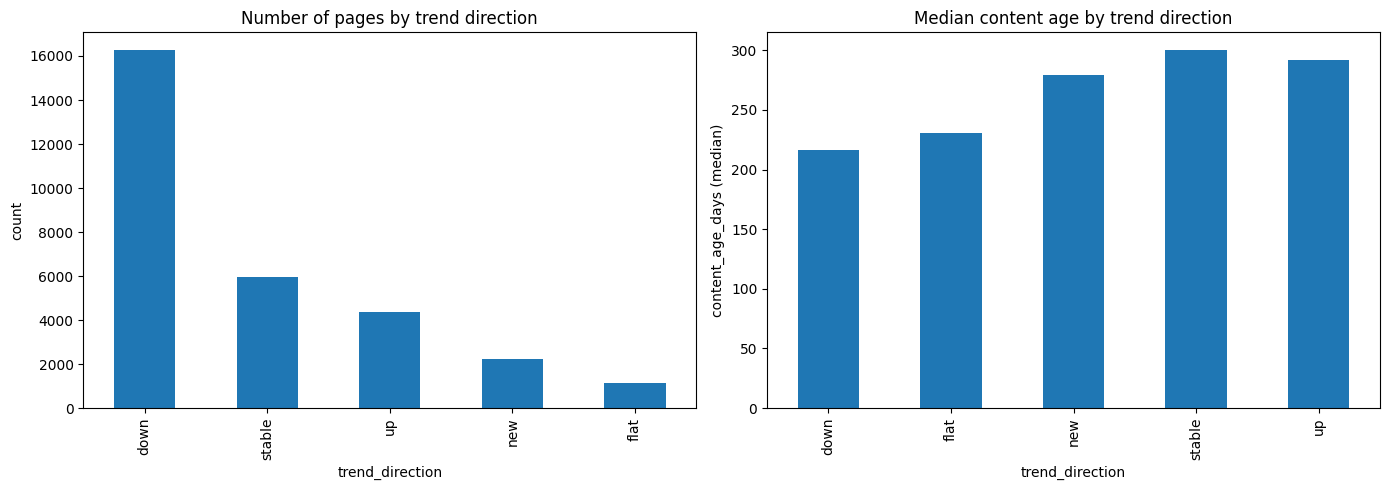

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df["trend_direction"].value_counts().plot(kind="bar", ax=axes[0], title="Number of pages by trend direction", ylabel="count")
df.groupby("trend_direction")["content_age_days"].median().plot(kind="bar", ax=axes[1], title="Median content age by trend direction", ylabel="content_age_days (median)")

plt.tight_layout()
plt.show()

The starter dataset has enough examples across all trend directions (16,262
declining pages alone, not a rare-event problem), and 73.4% of pages have
real traffic volume to learn from. More importantly, the "obvious" signal
doesn't hold: declining pages actually have the youngest median age (216
days), not the oldest. That's exactly the kind of counter-intuitive pattern
a simple hand-rule would miss but a model might pick up, which is why this
lane is worth building out further with proper future-window labels on the
full warehouse.

## 4. Careful words: what I can and can't claim

*Write what your work will be able to say (observed, directional, decision-support) — and what it never will (causal proof, 'predicting Google').*

**What I can claim:**
- Observed patterns in the anonymized starter and warehouse data (like the
  age-vs-decline relationship above).
- Directional signals: whether a feature tends to associate with future
  decline or growth, not a guarantee for any single page.
- Decision-support: a ranked list that helps a reviewer prioritize where to
  look first, given limited review capacity.
- Model performance measured honestly against a baseline, using a proper
  time-aware or client-grouped validation split.

**What I can't claim:**
- That I've proven what causes a page to decline or recover, no causal
  experiment was run, only observational data.
- That a refresh or content change will cause a page to recover, unless a
  real experiment (like an A/B test) tested that specifically.
- Anything about how Google's actual ranking algorithm works. I only see
  observable outcomes (impressions, clicks, position), never the algorithm
  itself.
- That any single prediction is certain. Even a strong model will be wrong
  on individual pages, it's a prioritization tool, not a guarantee.

I'll keep using words like "observed," "associated with," "directional," and
"decision-support" throughout, and avoid words like "proves," "causes," or
"predicts Google."

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.